In [1]:
# Install the required packages
# !pip install pandas numpy matplotlib scikit-learn torch ucimlrepo

# Import the libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report)

np.random.seed(123)
torch.manual_seed(123)

# Load the dataset

In [3]:
data = pd.read_csv('online_shoppers_intention.csv')
data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
# Split data into X(every column except Revenue) and y(Revenue)
X = data.drop(columns=['Revenue'])
y = data['Revenue'].astype(int) # Now it is 0 of Revenue = False; Otherwise, 1

# Basic EDA

In [5]:
# Basic EDA
print(X.describe())

       Administrative  Administrative_Duration  Informational  \
count    12330.000000             12330.000000   12330.000000   
mean         2.315166                80.818611       0.503569   
std          3.321784               176.779107       1.270156   
min          0.000000                 0.000000       0.000000   
25%          0.000000                 0.000000       0.000000   
50%          1.000000                 7.500000       0.000000   
75%          4.000000                93.256250       0.000000   
max         27.000000              3398.750000      24.000000   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
count            12330.000000    12330.000000             12330.000000   
mean                34.472398       31.731468              1194.746220   
std                140.749294       44.475503              1913.669288   
min                  0.000000        0.000000                 0.000000   
25%                  0.000000        7.00000

In [6]:
print(X.isnull().sum()) #There is no null. good

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
dtype: int64


In [7]:
print(y.value_counts(normalize=True)) # we can see only 15 percents of the visit resulted in purchase

Revenue
0    0.845255
1    0.154745
Name: proportion, dtype: float64


([<matplotlib.axis.XTick at 0x172ff6f90>,
 [Text(0, 0, 'No Purchase'), Text(1, 0, 'Purchase')])

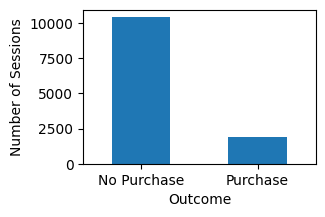

In [8]:
plt.figure(figsize=(3, 2))

y.value_counts().plot(kind="bar")
plt.xlabel("Outcome")
plt.ylabel("Number of Sessions")
plt.xticks([0, 1], ["No Purchase", "Purchase"], rotation=0)


# Train / Validation / Test

In [9]:
# We're going to use approximately: 70% training, 15% validation, and 15% testing

from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=123, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=.15/.85, random_state=123, stratify=y_train_val)

print("\nDataset sizes:", "Training:", X_train.shape, "| Validation:", X_val.shape, "| Testing:", X_test.shape)

# I used stratify to keep approximately the same percentage of Revenue = 1 in each split.
print("\nPurchase percentage:", "Training:", y_train.mean().round(3), "| Validation:", y_val.mean().round(3), "| Testing:", y_test.mean().round(3))


Dataset sizes: Training: (8630, 17) | Validation: (1850, 17) | Testing: (1850, 17)

Purchase percentage: Training: 0.155 | Validation: 0.155 | Testing: 0.155


# Prepare Numeric and Categorical Data

In [10]:
# NN need numbers!
# For categorical columns, I convert them into numbers & for numeric columns, I scale them.
categorical_columns = ["Month", "OperatingSystems", "Browser", "Region", "TrafficType", "VisitorType", "Weekend"]
numeric_columns = list(X.columns.difference(categorical_columns))

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[("numeric", StandardScaler(), numeric_columns), 
                  ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_columns) ]  )


# To prevent data leakage, I only FIT preprocessing on the training data. However, Validation and test data are only transformed.
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Convert Data to PyTorch Tensors & Convert to Datasets

In [11]:
X_train_processed.dtype

dtype('float64')

In [12]:
# It is better to convert it to float32 for PyTorch. We consider it for converting the data to tensors.
# Also, as our processed data is read through pandas, it is better to convert it to numpy, and then into tensors.
X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_processed, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.to_numpy(), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create Dataloaders

In [13]:
# We use Mini-batch Gradient Descent
batch_size = 64
# we want to have a MINI-BATCH training: 64 observations -> prediction -> loss -> gradient -> update weights
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [14]:
# This project is trained on the CPU because the dataset and neural network are relatively small. 
# PyTorch can also use GPU acceleration (CUDA or MPS) when compatible hardware is available.
device = torch.device("cpu")

# Create Neural Network

In [15]:
# I design a NN that has this structure: 
# Input features -> 64 neurons -> ReLU -> Dropout 20% -> Dropout -> 32 neurons -> ReLU -> 1 output
class PurchaseNet(nn.Module): # Create my own neural network using PyTorch's NN system (nn.Module).
    def __init__(self, input_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64), # Take all input features and connect them to 64 neurons.
            nn.ReLU(), # the activation function of max(0,a)
            nn.Dropout(0.20), # I add it to prevent overfitting. Can be deleted
            nn.Linear(64, 32), # Take the information from those 64 neurons and pass it to 32 neurons.
            nn.ReLU(),
            nn.Linear(32, 1) # Produce one final number. Note that az we use ReLU, it is not a probability.
        )

    def forward(self, x):
        return self.network(x).squeeze(1)

input_size = X_train_processed.shape[1]
model = PurchaseNet(input_size = input_size)
print(model)

PurchaseNet(
  (network): Sequential(
    (0): Linear(in_features=73, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Loss Function

In [16]:
# I use BCEWithLogitsLoss as it combines Sigmoid + Binary Cross Entropy
criterion = nn.BCEWithLogitsLoss()

## Optimizer

In [17]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) #Adam decides HOW to change the weights using the gradients calculated during backpropagation.

# Train & Validate the NN

## ONE IMPORTANT NOTE:

In [18]:
# The number of epochs is important because training a neural network for too long can cause overfitting.
# We use the validation set to monitor whether the model is still generalizing well to unseen data.

# Initially, I tested a much larger number of epochs (150). Although the training loss continued to decrease, the validation loss 
# started to increase and became much higher than the training loss. This indicated that the model was overfitting the training data.

# So, I reduced the number of epochs and compared the training and validation losses again.
# Based on the validation-loss curve that you can find below, the best performance was observed at around 7 epochs, where
# the validation loss was at its minimum and remained close to the training loss.
# So, I use 7 epochs for the final model.

epochs = 7

In [19]:
best_val_loss = float("inf")
train_losses = []
val_losses = []

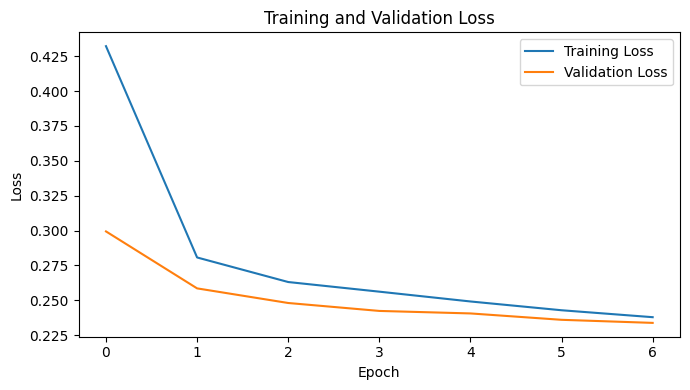

In [20]:
# Now, we want to implement whatever we defined above: 
# 1. Predict -> 2. Calculate loss -> 3. Set gradients zero -> 4. Backpropagation -> 5. Update Weights
for epoch in range(epochs):
    ## Training 
    model.train()
    total_train_loss = 0
    for X_batch, y_batch in train_loader:
        # 1. Predict
        logits = model(X_batch)
        
        # 2. Calculate loss
        loss = criterion(logits, y_batch)

        # 3. Set gradients zero
        optimizer.zero_grad()

        # 4. Backpropagation (Calculate gradients)
        loss.backward()

        # 5. Update Weights
        optimizer.step()

        total_train_loss += loss.item()


    average_train_loss = (total_train_loss / len(train_loader))
    train_losses.append(average_train_loss)

    ## Validation
    model.eval()
    total_val_loss = 0
    
    with torch.no_grad(): # No gradients needed during validation
        for X_batch, y_batch in val_loader:
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_val_loss += loss.item()

    average_val_loss = (total_val_loss/ len(val_loader))
    val_losses.append(average_val_loss)

# Plot
plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig("training_validation_loss.png")
plt.show()


# Validation Predictions

In [21]:
# Now, I use the validation set to choose the classification threshold.
model.eval() # Put the model in evaluation mode
val_probabilities = []
val_true_labels = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        logits = model(X_batch) # Get the raw output (logits)
        probabilities = torch.sigmoid(logits) # Convert logits to probabilities between 0 and 1
        val_probabilities.extend(probabilities.numpy())
        val_true_labels.extend(y_batch.numpy())

# Convert lists to NumPy arrays
val_probabilities = np.array(val_probabilities)
val_true_labels = np.array(val_true_labels)

In [22]:
# We try different thresholds and select the one with the highest validation F1 score
thresholds = np.arange(0.10, 0.91, 0.05)
best_threshold = 0
best_f1 = 0

for threshold in thresholds:
    val_predictions = (val_probabilities >= threshold).astype(int)
    f1 = f1_score(val_true_labels, val_predictions)
    print(f"Threshold: {threshold:.2f} | " f"F1 Score: {f1:.3f}")
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("\nBest threshold:", round(best_threshold, 2))

Threshold: 0.10 | F1 Score: 0.576
Threshold: 0.15 | F1 Score: 0.637
Threshold: 0.20 | F1 Score: 0.660
Threshold: 0.25 | F1 Score: 0.673
Threshold: 0.30 | F1 Score: 0.671
Threshold: 0.35 | F1 Score: 0.678
Threshold: 0.40 | F1 Score: 0.669
Threshold: 0.45 | F1 Score: 0.665
Threshold: 0.50 | F1 Score: 0.660
Threshold: 0.55 | F1 Score: 0.638
Threshold: 0.60 | F1 Score: 0.621
Threshold: 0.65 | F1 Score: 0.573
Threshold: 0.70 | F1 Score: 0.536
Threshold: 0.75 | F1 Score: 0.452
Threshold: 0.80 | F1 Score: 0.311
Threshold: 0.85 | F1 Score: 0.210
Threshold: 0.90 | F1 Score: 0.048

Best threshold: 0.35


# Test the Data

In [23]:
model.eval() 
test_probabilities = []
test_true_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model(X_batch) 
        probabilities = torch.sigmoid(logits) 
        test_probabilities.extend(probabilities.numpy())
        test_true_labels.extend(y_batch.numpy())
        
# Convert the lists to NumPy arrays
test_probabilities = np.array(test_probabilities)
test_true_labels = np.array(test_true_labels)

test_predictions = (test_probabilities >= best_threshold).astype(int) #Now we implement the threshhold found

In [24]:
# calculate the final test metrics
accuracy = accuracy_score(test_true_labels, test_predictions)
precision = precision_score(test_true_labels, test_predictions)
recall = recall_score(test_true_labels, test_predictions)
f1 = f1_score(test_true_labels, test_predictions)
roc_auc = roc_auc_score(test_true_labels, test_probabilities)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1:.3f}")
print(f"ROC-AUC:   {roc_auc:.3f}")

Accuracy:  0.890
Precision: 0.630
Recall:    0.703
F1 Score:  0.664
ROC-AUC:   0.917


Text(0.5, 1.0, 'Confusion Matrix')

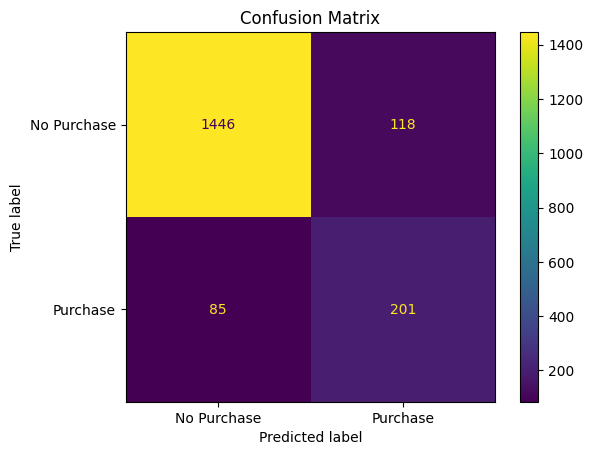

In [25]:
# Let's create confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
confusion = confusion_matrix(test_true_labels, test_predictions)

display = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=["No Purchase", "Purchase" ])
display.plot()
plt.title("Confusion Matrix")

# Compare with Logistic Regression

In [26]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=2000, class_weight="balanced")
baseline_model.fit(X_train_processed, y_train)
baseline_probabilities = (baseline_model.predict_proba(X_test_processed)[:, 1])
baseline_predictions = (baseline_probabilities >= 0.50).astype(int)

# Baseline Metrics
baseline_accuracy = accuracy_score(y_test, baseline_predictions)
baseline_precision = precision_score(y_test, baseline_predictions)
baseline_recall = recall_score(y_test, baseline_predictions)
baseline_f1 = f1_score(y_test, baseline_predictions)
baseline_roc_auc = roc_auc_score(y_test, baseline_probabilities)
baseline_pr_auc = average_precision_score(y_test, baseline_probabilities)

print("LogisticRegression Results:")
print(f"Accuracy: {baseline_accuracy:.3f}")
print(f"Precision: {baseline_precision:.3f}")
print(f"Recall: {baseline_recall:.3f}")
print(f"F1 Score: {baseline_f1:.3f}")
print(f"ROC-AUC:   {baseline_roc_auc:.3f}")
print(f"PR-AUC:    {baseline_pr_auc:.3f}")


LogisticRegression Results:
Accuracy: 0.845
Precision: 0.500
Recall: 0.766
F1 Score: 0.605
ROC-AUC:   0.896
PR-AUC:    0.648


In [27]:
# Compare models
results = pd.DataFrame({
    "Model": ["PyTorch Neural Network", "Logistic Regression"],
    "Accuracy": [accuracy,baseline_accuracy],
    "Precision": [precision, baseline_precision],
    "Recall": [recall, baseline_recall],
    "F1 Score": [f1, baseline_f1],
    "ROC-AUC": [roc_auc, baseline_roc_auc], 
})
print("\nModel Comparison:")
print(results.round(3))


Model Comparison:
                    Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  PyTorch Neural Network     0.890       0.63   0.703     0.664    0.917
1     Logistic Regression     0.845       0.50   0.766     0.605    0.896


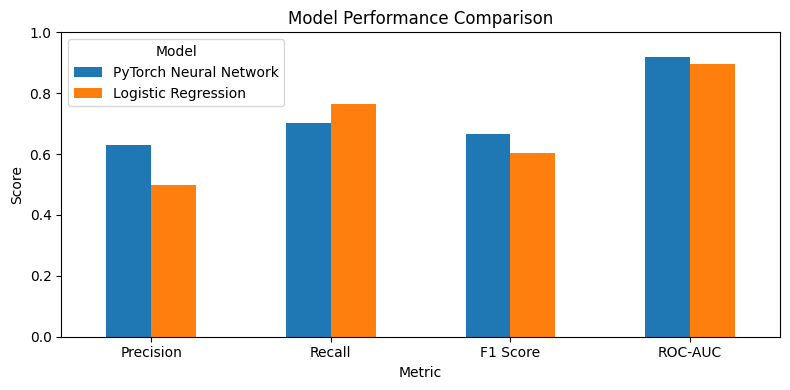

In [28]:
comparison_plot = (results.set_index("Model")[["Precision", "Recall", "F1 Score", "ROC-AUC"]])
comparison_plot.T.plot(kind="bar", figsize=(8, 4))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()